In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

In [10]:
def Milstein(t, y, glut_type=1, CC=36.5, CO=4.55, CS_plus1=0.3, CS_minus1=10.0, gamma1 =.003, gamma2 = 0.03, beta=10, t2=10000, delta1=1.1, delta2=0.3, briansconst=0.1):
    # t2 is the time of the second pulse for multi-pulse experiments 
    # and the frequency for periodic stimulus experiments
    
    R = y[0]
    RG = y[1]
    O1 = y[2]
    C1 = y[3]
    D1 = y[4]
    O2 = y[5]
    C2 = y[6]
    D2 = y[7]
    s = y[8]

#   exponential pulses
    if glut_type == 0:
        if  t<t2:
            glutamate = 0.01*(np.exp(-(t)/tauS))
        else:
            glutamate = 0.01*((np.exp(-(t)/tauS) + np.exp(-(t-t2)/tauS)))
        # 1/100 to make it in terms of 10mM instead of M
        
#   Square pulses
    if glut_type == 1:
        if (t>0 and t<1) or (t>500 and t<501) or (t>1000 and t<1001):   
            glutamate = 0.01
        else:
            glutamate = 0

#   Step increase 
    if glut_type == 2:
        if t>10 :   
            glutamate = 0.01
        else:
            glutamate = 0

#   Periodic square pulses
    if glut_type == 3:
        if t%(1000/t2)<=1:   ## Square pulse every 50ms for 20Hz. Change to 5 for 200Hz
            glutamate = 0.01
        else:
            glutamate = 0
            
#   Sinusodial signal
    if glut_type == 4:
        glutamate = 0.005*(1+np.sin(2*np.pi*(t2/1000)*t))
        
#   Paired Square Pulse
    if glut_type == 5:
        if t>=0 and t<50 or t>=t2 and t<50+t2:   
            glutamate = 0.01
        else:
            glutamate = 0
        
        
    
    dR_dt = k_minus1*RG - briansconst*glutamate*k_plus1*R #expon is equivalent to brianconst*s
    dRG_dt = briansconst*glutamate*k_plus1*R - k_minus1*RG + CO*C1 - CC*RG

    dC1_dt = CC*RG - CO*C1 + alpha*O1 - beta*C1 + gamma1*D1 - delta1*C1 + CS_minus1*C2 - CS_plus1*C1
    dO1_dt = beta*C1 - alpha*O1
    dD1_dt = delta1*C1 - gamma1*D1
    
    dC2_dt = CS_plus1*C1 - CS_minus1*C2 + alpha*O2 - beta*C2 + gamma2*D2 - delta2*C2
    dO2_dt = beta*C2 - alpha*O2
    dD2_dt = delta2*C2 - gamma2*D2
    
    ds_dt = -s/tauS # This variable didn't end up being used
    
#     dC3_dt = CS_plus2*C2 - CS_minus2*C3 + alpha*O3 - beta*C3 + gamma2*D3 - delta3*C3
#     dO3_dt = beta*C3 - alpha*O3
#     dD3_dt = delta3*C3 - gamma2*D3

    
    return [dR_dt, dRG_dt, dO1_dt, dC1_dt, dD1_dt, dO2_dt, dC2_dt, dD2_dt, ds_dt]

In [11]:
import pandas as pd
import os


### TARPless 1000 and 50000 runs

In [5]:
# Parameters
alpha = 6   # Deactivation rate
beta = 10    # Activation rate
k_plus1 = 1e4 # Binding rate of molecule to AMPAR (R to RG)
k_minus1 = 50  # Unbinding rate of molecule from AMPAR (RG to R)
gamma2 = .03
delta1 = 1.1    # Desensitization rate from D1 to RG*
delta2 = .3    # Desensitization rate from D2 to RG*2
tauS = 3
briansconst = 0.1



# Numerics
t0 = 0
T = 1000
dt = 0.01
t = np.linspace(t0, T, int(T/dt+1))

# Initial conditions
R_0 = 1.0
RG_0 = 0
O1_0 = 0
C1_0 = 0
D1_0 = 0
O2_0 = 0
C2_0 = 0
D2_0 = 0
s_0 = 0
y0 = [R_0, RG_0, O1_0, C1_0, D1_0, O2_0, C2_0, D2_0, s_0]

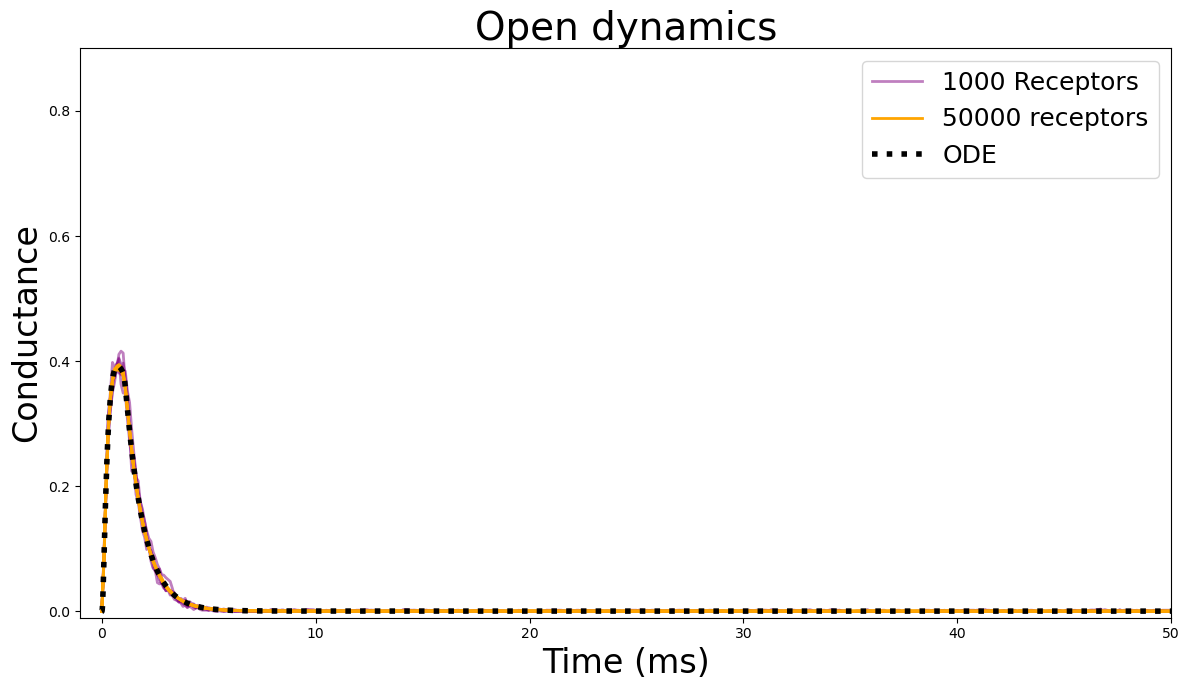

In [ ]:

# Setup paths and file details


### TARPless 1000 runs

base_path = r"C:/Users/brian/AMPA-Project/Data/"
file_prefix = "unTARPed_MonteCarlo1000runs_"
file_numbers = [1, 2, 3, 4, 5]

plt.figure(figsize=(12, 7))

# Loop through each file
for i in file_numbers:
    file_path = os.path.join(base_path, f"{file_prefix}{i}")
    
    try:
        # Tab-Separated from KineticModelBuilder
        # We skip the header to avoid the duplicate 'Time (s)' naming issue
        df = pd.read_csv(file_path, sep='\t', skiprows=1, header=None)
        
        # Column 8: Time for O1 | Column 9: O1 values
        # Column 14: Time for O2 | Column 15: O2 values
        time_axis = df.iloc[:, 8]
        total_open = df.iloc[:, 9] + 2*df.iloc[:, 15] # Summing O1 + O2
        # total_open = df.iloc[:, 11] + df.iloc[:, 17] # Summing O1 + O2
        
        # Plot each file as a separate line
        if i<5:
        	plt.plot(time_axis*1000, total_open, alpha=0.5, color='purple', linewidth=2.0)
                     
    except Exception as e:
        print(f"Could not read file {i}: {e}")

# Formatting the plot
plt.plot(time_axis*1000, total_open, label=f'1000 Receptors', alpha=0.5, color='purple', linewidth=2.0)



## TARPless 50000 runs

file_prefix = "unTARPed_MonteCarlo50000runs_"
file_numbers = [1, 2, 3, 4, 5]

# Loop through each file
for i in file_numbers:
    file_path = os.path.join(base_path, f"{file_prefix}{i}")
    
    try:
        # Tab-Separated from KineticModelBuilder
        # Skip the header to avoid the duplicate 'Time (s)' naming issue
        df = pd.read_csv(file_path, sep='\t', skiprows=1, header=None)
        
        # Column 8: Time for O1 | Column 9: O1 values
        # Column 14: Time for O2 | Column 15: O2 values
        time_axis = df.iloc[:, 8]
        total_open = df.iloc[:, 9] + 2*df.iloc[:, 15] # Summing O1 + O2
        # total_open = df.iloc[:, 11] + df.iloc[:, 17] # Summing O1 + O2
        
        # Plot each file as a separate line
        if i<5:
        	plt.plot(time_axis*1000, total_open, color='orange', linewidth=2.0)
                     
    except Exception as e:
        print(f"Could not read file {i}: {e}")


In [ ]:
plt.plot(time_axis*1000, total_open, label=f'50000 receptors', color='orange', linewidth=2.0)

sol_v = solve_ivp(Milstein, [0, 500], y0, args = (), dense_output=True,  rtol=1e-12, max_step=0.1)
plt.plot(sol_v.t[:], sol_v.y[2,:] + 2*sol_v.y[5,:], label = 'ODE', linewidth=4.0, linestyle=':', color='black')
# plt.plot(sol_v.t[:], sol_v.y[4,:] + sol_v.y[7,:], label = 'ODE', linewidth=4.0, linestyle=':', color='black')

plt.title('Open dynamics', fontsize=28)
plt.xlabel('Time (ms)', fontsize=24)
plt.ylabel('Conductance', fontsize=24)
plt.legend(fontsize=18)
# plt.xlim(-50, 1500)
# plt.xlim(-1, 10)
# plt.ylim(-0.01, 0.51)
plt.xlim(-1, 50)
plt.ylim(-0.01,0.9)
plt.tight_layout()

# plt.grid(True, linestyle='--', alpha=0.5)

# plt.savefig('unTARPed_allruns_O.pdf')

### TARPed 1000 runs and 50000 runs

In [7]:
# Parameters
alpha = 6   # Deactivation rate
beta = 100    # Activation rate
k_plus1 = 1e4 # Binding rate of molecule to AMPAR (R to RG)
k_minus1 = 50  # Unbinding rate of molecule from AMPAR (RG to R)
delta1 = 1.1    # Desensitization rate from D1 to RG*
delta2 = .3    # Desensitization rate from D2 to RG*2
tauS = 3
briansconst = 0.1

#     CC = 25.0      # Transition from RG to RG* (channel activating)
#     CO = 2.5     # Transition from RG* to RG (Channel deactivating)
#     CS_plus1 = 1.0   # Transition from RG* to RG*2
#     CS_minus1 = 3.4 # Transition from desensitized state RG*2 to RG*
#     gamma1  = .03 # Recovery rate?
#     gamma2 = .03

# Numerics
t0 = 0
T = 1000
dt = 0.01
t = np.linspace(t0, T, int(T/dt+1))

# Initial conditions
R_0 = 1.0
RG_0 = 0
O1_0 = 0
C1_0 = 0
D1_0 = 0
O2_0 = 0
C2_0 = 0
D2_0 = 0
s_0 = 0
y0 = [R_0, RG_0, O1_0, C1_0, D1_0, O2_0, C2_0, D2_0, s_0]

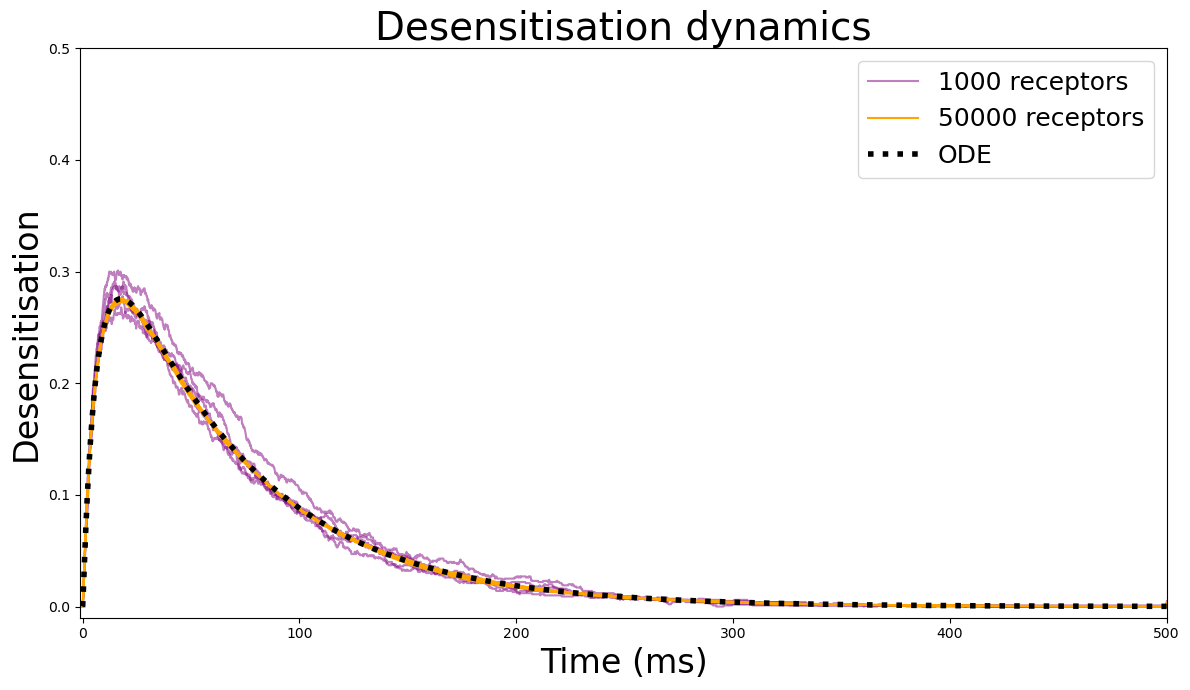

In [ ]:
# Setup paths and file details

#### TARPed 1000 runs

base_path = r"C:/Users/brian/AMPA-Project/Data/"
file_prefix = "TARPed_MonteCarlo1000runs_"
file_numbers = [1, 2, 3, 4, 5]

plt.figure(figsize=(12, 7))

# Loop through each file
for i in file_numbers:
    file_path = os.path.join(base_path, f"{file_prefix}{i}")
    
    try:
        # Tab-Separated from KineticModelBuilder
        # Skip the header to avoid the duplicate 'Time (s)' naming issue
        df = pd.read_csv(file_path, sep='\t', skiprows=1, header=None)
        
        # Column 8: Time for O1 | Column 9: O1 values
        # Column 14: Time for O2 | Column 15: O2 values
        time_axis = df.iloc[:, 10]
        # total_open = df.iloc[:, 9] + 2*df.iloc[:, 15] # Summing O1 + O2
        total_open = df.iloc[:, 11] + df.iloc[:, 17] # Summing O1 + O2
        
        # Plot each file as a separate line
        if i<5:
        	plt.plot(time_axis*1000, total_open, alpha=0.5, color='purple')
        
    except Exception as e:
        print(f"Could not read file {i}: {e}")

# Formatting the plot
plt.plot(time_axis*1000, total_open, label=f'1000 receptors', alpha=0.5, color='purple')



######TARPed 50000 runs

file_prefix = "TARPed_MonteCarlo50000runs_"
file_numbers = [1, 2, 3, 4, 5]

# Loop through each file
for i in file_numbers:
    file_path = os.path.join(base_path, f"{file_prefix}{i}")
    
    try:
        # Tab-Separated from KineticModelBuilder
        # We skip the header to avoid the duplicate 'Time (s)' naming issue
        df = pd.read_csv(file_path, sep='\t', skiprows=1, header=None)
        
        # Column 8: Time for O1 | Column 9: O1 values
        # Column 14: Time for O2 | Column 15: O2 values
        time_axis = df.iloc[:, 10]
        # total_open = df.iloc[:, 9] + 2*df.iloc[:, 15] # Summing O1 + O2
        total_open = df.iloc[:, 11] + df.iloc[:, 17] # Summing O1 + O2
        
        # Plot each file as a separate line
        if i<5:
        	plt.plot(time_axis*1000, total_open, color='orange')
        
    except Exception as e:
        print(f"Could not read file {i}: {e}")



In [ ]:
plt.plot(time_axis*1000, total_open, label=f'50000 receptors', color='orange')

sol_v = solve_ivp(Milstein, [0, 500], y0, args = (1, 25.0, 2.5, 1.0, 3.4, 0.03, 0.03, beta, 10000, delta1, delta2, briansconst), dense_output=True,  rtol=1e-12, max_step=0.1)
# plt.plot(sol_v.t[:], sol_v.y[2,:] + 2*sol_v.y[5,:], label = 'ODE', linewidth=4.0, linestyle=':', color='black')
plt.plot(sol_v.t[:], sol_v.y[4,:] + sol_v.y[7,:], label = 'ODE', linewidth=4.0, linestyle=':', color='black')
plt.title('Desensitisation dynamics', fontsize=28)
plt.xlabel('Time (ms)', fontsize=24)
plt.ylabel('Desensitisation', fontsize=24)
plt.legend(fontsize=18)
plt.xlim(-1, 500)
plt.ylim(-0.01,0.5)
plt.tight_layout()

# plt.xlim(-1, 20)

# plt.savefig('TARPed_allruns_D.pdf')